In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [2]:
df = pd.read_csv('Data2/resontors_S21_1.00-9.00GHz_0.0dBm_20260716_104330.csv')
sim_f0_kin_res = np.array([5.566,4.680,4.645,4.434,4.162,6.206])
#theo_f0_kin_res = np.array([8.51077059,7.49291156,8.20177958,
                            #7.14371248,7.8479671,8.8257005])

In [19]:
mask = (df['Frequency (GHz)'] > 3) & (df['Frequency (GHz)'] < 6)
inverted = -df['Magnitude (dB)'][mask]
#Find the peaks of the data in 100MHz range
peaks,_ = find_peaks(inverted,height=55,distance=90)

#Remove Peaks based on inspection
#remove = [0,1,3,4,5,7,17,19,20,21,22,24,25,26,28,29,32]
#peaks = np.delete(peaks,remove)


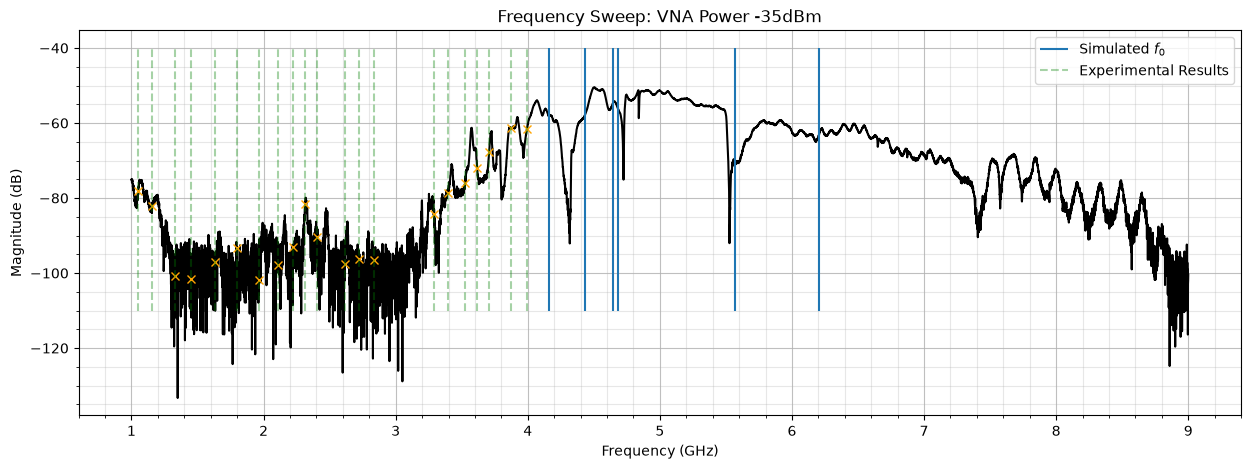

In [20]:
plt.figure(figsize=(15,5))
plt.title('Frequency Sweep: VNA Power -35dBm')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequency (GHz)')
plt.plot(df['Frequency (GHz)'],
         df['Magnitude (dB)'],
         c='black',ls='-')
plt.plot(df['Frequency (GHz)'][peaks],
         df['Magnitude (dB)'][peaks],
         'x',color='orange')

plt.vlines(sim_f0_kin_res,ymin=-110,ymax=-40,label=r'Simulated $f_0$')
#plt.vlines(theo_f0_kin_res,ymin=-110,ymax=-40,colors='r',label=r'Theoretical $f_0$')
plt.vlines(df['Frequency (GHz)'][peaks],
           ymin=-110,ymax=-40,colors='green',ls='--',alpha=0.35,label='Experimental Results')

plt.grid(which='major',alpha=0.8)
plt.grid(which='minor',alpha=0.3)
plt.legend(loc='best')
plt.minorticks_on()
plt.show()


In [5]:
print(df['Frequency (GHz)'][peaks])
csv = df['Frequency (GHz)'][peaks]
csv.to_csv('out.csv',index=True)

40      1.040
213     1.213
350     1.350
568     1.568
766     1.766
937     1.937
1073    2.073
1285    2.285
1424    2.424
1599    2.599
1828    2.828
2051    3.051
2186    3.186
2327    3.327
2468    3.468
2630    3.630
2802    3.802
2966    3.966
3182    4.182
3318    4.318
3725    4.725
4387    5.387
4527    5.527
4666    5.666
4871    5.871
5026    6.026
5182    6.182
5332    6.332
5595    6.595
5768    6.768
5936    6.936
6092    7.092
6268    7.268
6407    7.407
6576    7.576
6741    7.741
6949    7.949
7096    8.096
7245    8.245
7402    8.402
7572    8.572
7721    8.721
7859    8.859
7997    8.997
Name: Frequency (GHz), dtype: float64




In [6]:
window = 100  # points either side of the peak

n = len(peaks)  # your 28 indices

#Define Plots
fig, axs = plt.subplots(n, 1, figsize=(8, 2.5 * n), layout='constrained', squeeze=False)
axs = axs.flatten()

#Simplfy
freq = df['Frequency (GHz)']
mag = df['Magnitude (dB)']

#Loop over all peaks and plot figures
for ax, idx in zip(axs, peaks):
    #Frequency Bounds of plot
    lo = max(idx - window, 0)        #Protects from negative index
    hi = min(idx + window, len(df))  #Protects from out of bound indexs

    #Plot data from Ranges
    ax.plot(freq.iloc[lo:hi], mag.iloc[lo:hi], c='black', ls='-', alpha=0.5)
    ax.plot(freq.iloc[idx], mag.iloc[idx], 'x', color='red')

    #Label Figures
    ax.set_title(f'Index {idx}', fontsize=9)

plt.show()